Supponiamo di misurare questi 5 diametri. Suppongo di effettuare misurazioni indipendenti e che esse si distribuiscano ognuna singolarmente come una gaussiana con valor medio $\mu$ e con una $\sigma$ nota $\Rightarrow X_i \sim \mathcal N(\mu ,\sigma^2)$

Ora si devono riporre queste sferette di diametro incognito in uno cassetto e per farlo si deve conoscere il valore giusto del diametro di tali sferette. Allora si fanno due ipotesi. L'ipotesti di lavoro $H_0$ secondo cui il diametro è $d_0=1.5\ cm$ ed un'ipotesi altrnativa $H_1$ secondo cui il diametro è $d_1=1.6\ cm$.

Chiaramente la distribuzione delle singole misure sotto ipotesi $H_0$ diventa $X_i \sim \mathcal N(d_0,\sigma^2)$ mentre sotto ipotesi $H_1$ diventa $X_i \sim \mathcal N(d_1,\sigma^2)$. Supponiamo unoltre una deviazione standard $\sigma = 0.05 cm$ per tutte quante le misure.

Ora l'idea per eseguire il test statistico è costruire la seguente statistica sulla base del campione raccolto $T(X)= \bar X=\frac1n\sum X_i$, ovvero la media aritmetica.

se le X_i sono gaussiane indipendenti, allora la distribuzione della media aritmetica è $\bar X \sim \mathcal N\left(\mu,\frac{\sigma^2}{n}\right)$ che sotto ipotesi $H_0$ diventerà $\bar X \sim \mathcal N\left(d_0,\frac{\sigma^2}{n}\right)$ accompagnata dall'errore sulla media $\sigma_{\bar d}=\frac{\sigma}{\sqrt n}$.

L'idea del test che vogliamo condurre prevede di identificare un certo valore $d_\alpha $ di soglia che faccia da confine tra la regione di accettazione e la regione critica. Una volta identificato questo valore di soglia, estraiamo dal nostro campione la media aritmetica e nel caso in cui venga verificato che $\bar X>d_\alpha$, allora significa che mi trovo nella regione di rifiuto e quindi rigetto l'ipotesi di lavoro $H_0$ in favore dell'ipotesi alternativa $H_1$.

Il tutto quindi si riduce ad una corrett ascelta di $d_\alpha$ che non va preso a caso ma va fissato in maniera tale da soddisfare la significatività statistica $\alpha$ che vogliamo per il nostro test. In particolare vogliamo effettuare un test al $95 \%$ di confidenza e dunque richiedo una significatività $\alpha = 0.05$.

Ricordiamo che $\alpha$ è un errore del primo tipo, ovvero l'errore che commetto scartando $H_0$ quando questa in realtà è vera. Pertanto $\alpha$ deve coincidere proprio con la probabilità di rifiuto di $H_0$ sotto l'ipotesi $H_0$ (significa che $H_0$ è vera). Noi però abbiamo detto che scartiamo $H_0$ quando $\bar X>d_\alpha$.

Posso dunque definire $\alpha=P(\bar X>d_\alpha\mid H_0)=0.05$  (1) ed invertendo questa equazione posso ricavare $d_\alpha$. Spesso tuttavia conviene passare alla variabiel gaussiana standardizzata. Noi abbiamo detto che sotto ipotesi $H_0$ si ha che $\bar X \sim \mathcal N\left(d_0,\frac{\sigma^2}{n}\right)$ e quindi posso costruire una variabile gaussiana standardizzata come $Z= \frac{\bar X-d_0}{\sigma/\sqrt n}$ e si avrà che $Z\sim\mathcal N(0,1)$.

Dobbiamo però riscrivere (1) in funzione di $Z$:

$\alpha=P(\bar X>d_\alpha\mid H_0)= P\left(\bar X>d_\alpha \mid H_0\right)=P\left(\frac{\bar X-d_0}{\sigma/\sqrt n}>\frac{d_\alpha-d_0}{\sigma/\sqrt n}\mid H_0\right) = P(Z>k_\alpha)=0.05$ (2)

dove: $k_\alpha= \frac{d_\alpha-d_0}{\sigma/\sqrt n}$

Adesso indichiamo la cumulativa della gaussiana standard calcolata in $k_\alpha$ come $F_\mathcal{N}\ (k_{\alpha})$.

Si ha che la (2) può essere riscritta in termini di questa cumulativa e questo proprio perchè:

$P(Z>k_\alpha)=1-F_\mathcal{N}\ (k_{\alpha})=0.05$



In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.optimize import fsolve
from IPython.display import display, Math

In [19]:
mu=0
sigma=1
k_alpha=fsolve(lambda x: 1-norm.cdf(x,mu,sigma)-0.05,x0=1)[0]

display(Math(fr"\text{{Invertendo l'equazione abbiamo determinato un valore di }} k_\alpha = {k_alpha:.3f}"))

<IPython.core.display.Math object>

Adesso ricordiamo che $k_\alpha=
\frac{d_\alpha-d_0}{\sigma/\sqrt n}$ con $d_0=1.5$

In [24]:
d_alpha =fsolve(lambda x: (x-1.5)/(0.05/np.sqrt(5))-1.645,x0=1)[0]

display(Math(fr"\text{{Invertendo l'equazione abbiamo determinato un valore di }} d_\alpha = {d_alpha:.2f}\ cm"))

<IPython.core.display.Math object>

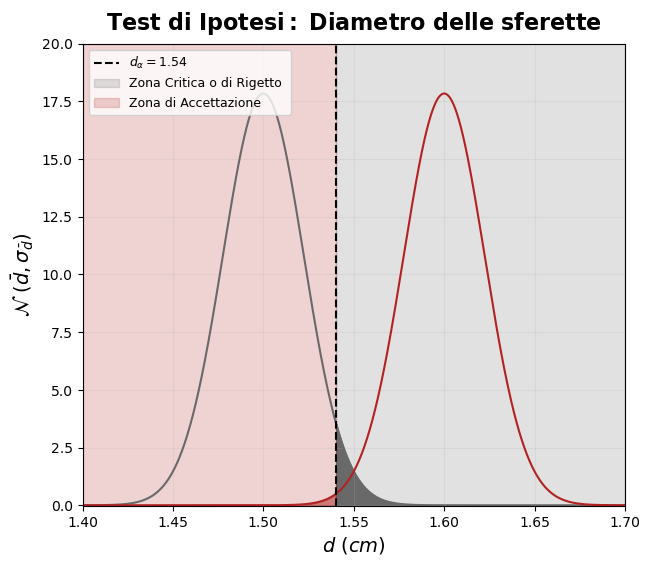

In [28]:
x_cut= 1.54
fig,ax = plt.subplots(figsize=(7,6))

ax.plot(xs,n1, color='dimgray')
ax.plot(xs,n2,color='firebrick')
ax.axvline(x_cut,linestyle='--',label=r'$\mathit{d_{\alpha}=}$' + f'{x_cut:.2f}',color='black')
mask = xs > x_cut

ax.fill_between(xs[mask],
                norm.pdf(xs[mask],mu1,sigma_d),
                color='dimgray'
                )

mask = xs<x_cut

ax.fill_between(xs[mask],
                norm.pdf(xs[mask],mu2,sigma_d),
                color='firebrick',
                alpha=0.5
              )

mask = (xs>x_cut)

ax.fill_between(xs[mask],
                20,
                color='dimgray',
                alpha=0.2,
                label='Zona Critica o di Rigetto ',
                )
mask = (xs<x_cut)

ax.fill_between(xs[mask],
                20,
                color='firebrick',
                alpha=0.2,
                label='Zona di Accettazione',
                )
ax.set_title(r'$\mathbf{Test\ di\ Ipotesi:\ Diametro\ delle\ sferette}$',
             fontsize=16,
             pad=10)
ax.set_xlabel(r'$\mathit{d\ (cm)}$',
             fontsize=14)
ax.set_ylabel(r'$\mathit{\mathcal{N}\ (\bar d, \sigma _\bar d)}$',
             fontsize=14)
ax.set_ylim(-0.02,20)
ax.set_xlim(1.4,1.7)
plt.legend(loc='upper left',
           fontsize=9)
plt.grid(True,alpha=0.2)



Una volta che ho stabilito le zone di rigetto e la zona critica, vado a fare la mia misura della media e in base a dove mi esce accetto $H_0 $ o accetto $H_1$.


Se invece di avere 5 palline mi ritrovo con una sola di cui misuro il valore del diametro, chiaramente avrò un errore più grande sulla media (che poi vabbè non posso fare perchè ho una sola pallina quindi che cazz e media posso fare). Supponiamo che questo singolo valore di diametro mi venga identico al valore della media che avevo calcolato, solo che ora l’errore sarà $\sigma_{\bar d}=0.05/1=0.05$. Quindi le distribuzioni di allargano e si abbassano, le pdf saranno molto più sovrapposte e le nuove regioni di accettazione e di rifiuto saranno le seguenti:


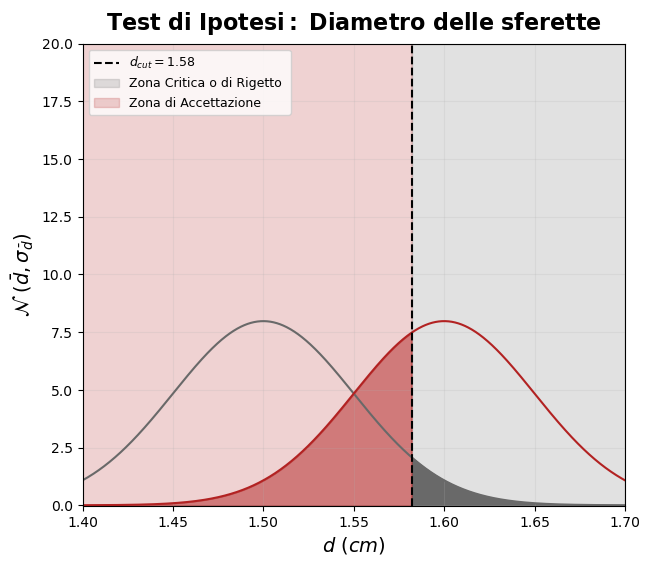

In [29]:
mu1=1.5
mu2=1.6
sigma_d=0.05
xs = np.linspace(1.4,1.7,1000)
n1=norm.pdf(xs,mu1,sigma_d)
n2=norm.pdf(xs,mu2,sigma_d)

alpha=0.05
x_cut= norm.ppf(1-alpha, mu1, sigma_d)
fig,ax = plt.subplots(figsize=(7,6))

ax.plot(xs,n1, color='dimgray')
ax.plot(xs,n2,color='firebrick')
ax.axvline(x_cut,linestyle='--',label=r'$\mathit{d_{cut}=}$' + f'{x_cut:.2f}',color='black')
mask = xs > x_cut

ax.fill_between(xs[mask],
                norm.pdf(xs[mask],mu1,sigma_d),
                color='dimgray'
                )

mask = xs<x_cut

ax.fill_between(xs[mask],
                norm.pdf(xs[mask],mu2,sigma_d),
                color='firebrick',
                alpha=0.5
              )

mask = (xs>x_cut)

ax.fill_between(xs[mask],
                20,
                color='dimgray',
                alpha=0.2,
                label='Zona Critica o di Rigetto ',
                )
mask = (xs<x_cut)

ax.fill_between(xs[mask],
                20,
                color='firebrick',
                alpha=0.2,
                label='Zona di Accettazione',
                )
ax.set_title(r'$\mathbf{Test\ di\ Ipotesi:\ Diametro\ delle\ sferette}$',
             fontsize=16,
             pad=10)
ax.set_xlabel(r'$\mathit{d\ (cm)}$',
             fontsize=14)
ax.set_ylabel(r'$\mathit{\mathcal{N}\ (\bar d, \sigma _\bar d)}$',
             fontsize=14)
ax.set_ylim(-0.02,20)
ax.set_xlim(1.4,1.7)
plt.legend(loc='upper left',
           fontsize=9)
plt.grid(True,alpha=0.2)
